<a href="https://colab.research.google.com/github/satvikjoshi139-lab/Quantum_Computing/blob/main/Quantum_algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d2a4b3a539e2a1f3508a164d4e7289363f3984ceac656f0a3e8da087083ef69e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# 1. Deutsch’s Algorithm
Determines if a 1-bit function is constant or balanced in one query. This script tests a balanced oracle.

Execution Results (Balanced='1', Constant='0'): {'1': 1024}


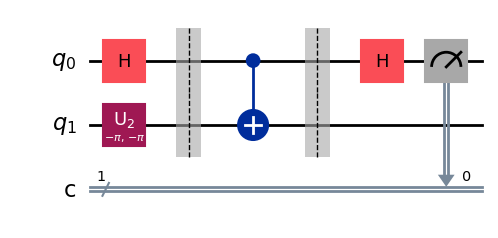

In [ ]:
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler

# 1. Abstract Circuit Formulation
# Note: When creating a QuantumCircuit(2, 1) without explicit naming,
# Qiskit names the classical register "c" by default.
qc = QuantumCircuit(2, 1)

# Step A: Initialize states into phase-kickback setup
qc.x(1)
qc.h(0)
qc.h(1)
qc.barrier()

# Step B: Balanced Oracle (f(x) = x)
qc.cx(0, 1)
qc.barrier()

# Step C: Interference transformation and measurement
qc.h(0)
qc.measure(0, 0)

# 2. Modern 2026 Compilation
backend = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(qc)

# 3. Primitive Execution (2026 Norms)
sampler = StatevectorSampler()
job = sampler.run([(isa_circuit)])
result = job.result()

# --- IBM 2026 TRAINING ALIGNMENT UPDATE ---
# V2 Primitives return an array of PubResults. We extract index [0].
# Data extraction calls the register attribute ".c" dynamically.
pub_result = result[0]
counts = pub_result.data.c.get_counts()

print("Execution Results (Balanced='1', Constant='0'):", counts)
isa_circuit.draw('mpl')



# 2. Deutsch-Jozsa Algorithm
Scales Deutsch's concept to an \(n\)-bit function. This script runs a balanced oracle across 3 data qubits.

Execution Results (Balanced='111', Constant='000'): {'111': 1024}


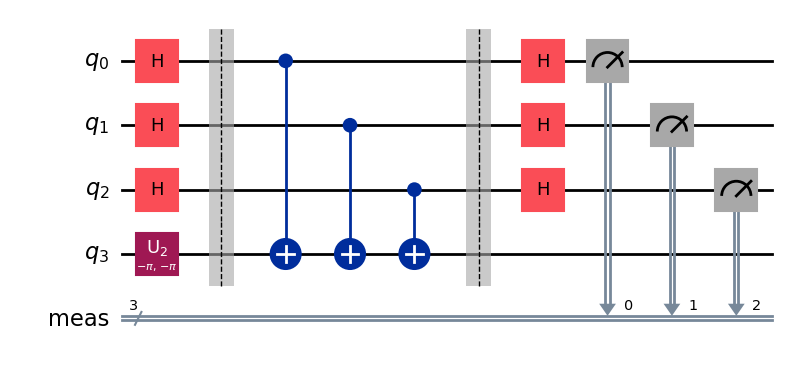

In [ ]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler

# ----------------------------------------------------
# Step 1: Construct the Abstract Algorithmic Circuit
# ----------------------------------------------------
qr = QuantumRegister(4, name="q")
cr = ClassicalRegister(3, name="meas")
abstract_circuit = QuantumCircuit(qr, cr)

# Step A: Initialize states into phase-kickback setup
abstract_circuit.x(3)
abstract_circuit.h(qr)
abstract_circuit.barrier()

# Step B: Balanced Oracle
abstract_circuit.cx(0, 3)
abstract_circuit.cx(1, 3)
abstract_circuit.cx(2, 3)
abstract_circuit.barrier()

# Step C: Bring data qubits out of superposition
abstract_circuit.h([0, 1, 2])

# Step D: Measure the 3 data qubits into our named classical register
abstract_circuit.measure([0, 1, 2], [0, 1, 2])

# ----------------------------------------------------
# Step 2: Establish Backend and Transpile to ISA
# ----------------------------------------------------
backend = AerSimulator()
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pass_manager.run(abstract_circuit)

# ----------------------------------------------------
# Step 3: Modern Primitive Execution & Data Retrieval
# ----------------------------------------------------
sampler = StatevectorSampler()
job = sampler.run([(isa_circuit)])
result = job.result()  # This returns a global PrimitiveResult container

# --- 2026 IBM NORM CORRECTION ---
# 1. Grab index [0] to extract the specific PubResult object from the list
# 2. Access the DataBin through .data, then target your register name (.meas)
pub_result = result[0]
counts = pub_result.data.meas.get_counts()

print("Execution Results (Balanced='111', Constant='000'):", counts)
isa_circuit.draw('mpl')


# 3. Grover’s Search Algorithm
Finds a marked element in an unsorted database. This handles a 2-qubit register searching for the state (ket 11)

Grover Target Element Found (Expecting '11'): {'11': 1024}


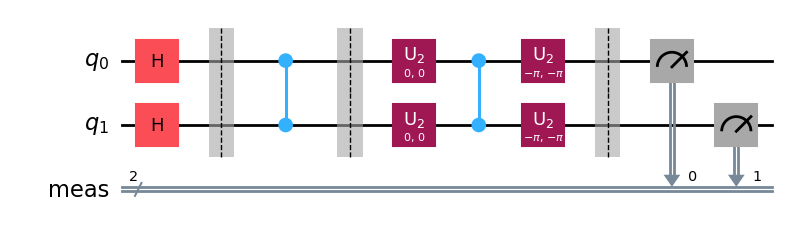

In [ ]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler

# ----------------------------------------------------
# Step 1: Construct the Abstract Search Circuit
# ----------------------------------------------------
qr = QuantumRegister(2, name="q")
cr = ClassicalRegister(2, name="meas")
abstract_circuit = QuantumCircuit(qr, cr)

# Step A: Uniform Superposition
abstract_circuit.h(qr)
abstract_circuit.barrier()

# Step B: Oracle (Marks state |11> by flipping its phase)
abstract_circuit.cz(0, 1)
abstract_circuit.barrier()

# Step C: Diffusion Operator (Amplification)
abstract_circuit.h(qr)
abstract_circuit.x(qr)
abstract_circuit.cz(0, 1)
abstract_circuit.x(qr)
abstract_circuit.h(qr)
abstract_circuit.barrier()

# Step D: Named Register Measurement
abstract_circuit.measure(qr, cr)

# ----------------------------------------------------
# Step 2: Establish Backend and Transpile to ISA
# ----------------------------------------------------
backend = AerSimulator()
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pass_manager.run(abstract_circuit)

# ----------------------------------------------------
# Step 3: Modern Primitive Execution & Data Retrieval
# ----------------------------------------------------
sampler = StatevectorSampler()
job = sampler.run([(isa_circuit)])
result = job.result()

# Extract the first PubResult object from the PrimitiveResult array
pub_result = result[0]
counts = pub_result.data.meas.get_counts()

print("Grover Target Element Found (Expecting '11'):", counts)
isa_circuit.draw('mpl')


# 4. Shor’s Factoring Algorithm (Core Routine)

Phase Estimation Readout (Used to compute the factor period): {'0010': 22, '0000': 259, '0101': 83, '1111': 127, '0011': 46, '0001': 104, '1110': 15, '1011': 85, '0110': 91, '1010': 105, '1101': 47, '1001': 22, '0111': 18}


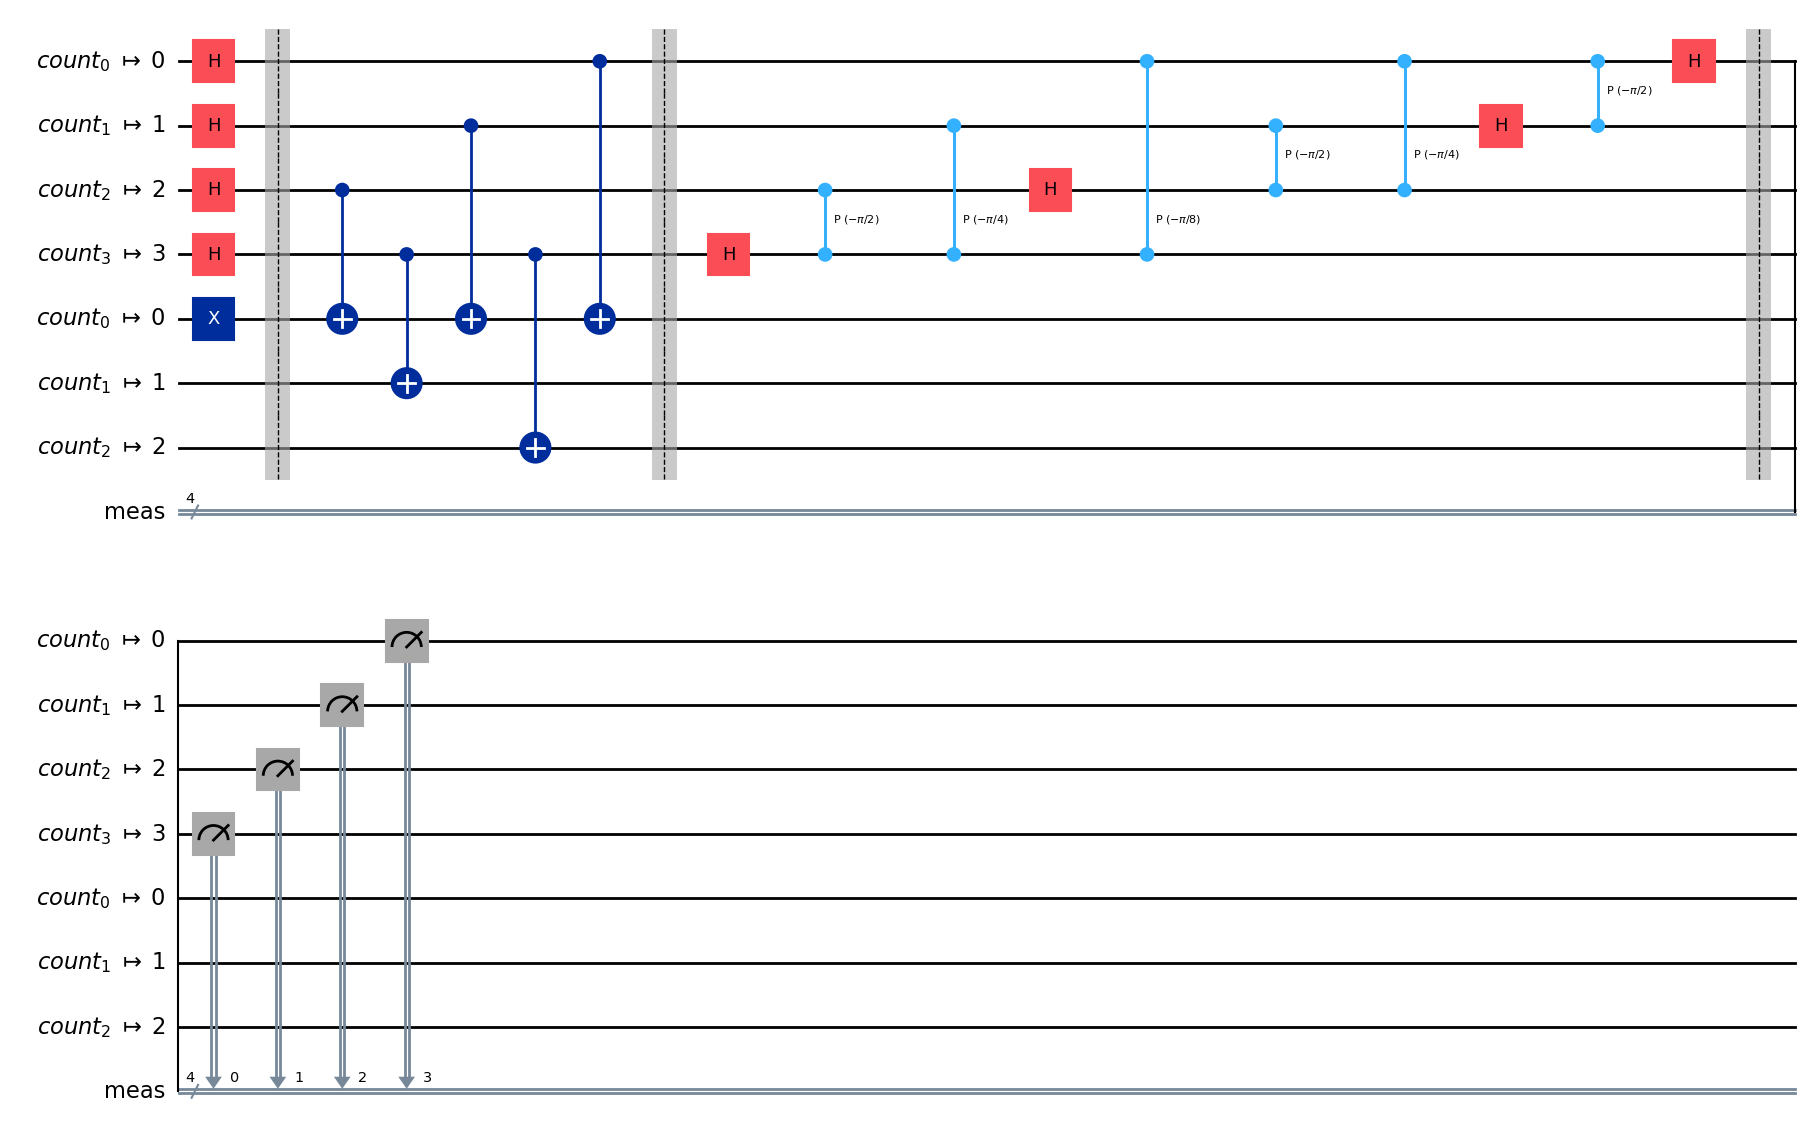

In [ ]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.circuit.library import QFTGate  # Updated for Qiskit 2.x/3.0 compliance
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler

# ----------------------------------------------------
# Step 1: Construct the Abstract Algorithmic Circuit
# ----------------------------------------------------
qr_count = QuantumRegister(4, name="count")
qr_target = QuantumRegister(4, name="target")
cr_meas = ClassicalRegister(4, name="meas")
abstract_circuit = QuantumCircuit(qr_count, qr_target, cr_meas)

# Step A: Initialize workspace
abstract_circuit.h(qr_count)
abstract_circuit.x(qr_target[0])
abstract_circuit.barrier()

# Step B: Modular Exponentiation Engine (a=7 mod 15)
abstract_circuit.cx(qr_count[3], qr_target[1])
abstract_circuit.cx(qr_count[3], qr_target[2])
abstract_circuit.cx(qr_count[2], qr_target[0])
abstract_circuit.cx(qr_count[1], qr_target[0])
abstract_circuit.cx(qr_count[0], qr_target[0])
abstract_circuit.barrier()

# Step C: Inverse QFT (Exam Standard: Use QFTGate and apply .inverse())
abstract_circuit.append(QFTGate(num_qubits=4).inverse(), qr_count)
abstract_circuit.barrier()

# Step D: Measure the counting qubits
abstract_circuit.measure(qr_count, cr_meas)

# ----------------------------------------------------
# Step 2: Establish Backend and Transpile to ISA
# ----------------------------------------------------
backend = AerSimulator()
pass_manager = generate_preset_pass_manager(optimization_level=2, backend=backend)
isa_circuit = pass_manager.run(abstract_circuit)

# ----------------------------------------------------
# Step 3: Modern Primitive Execution & Data Retrieval
# ----------------------------------------------------
sampler = StatevectorSampler()
job = sampler.run([(isa_circuit)])
result = job.result()

# --- EXAM CORRECTION: Fetch index 0 out of the PrimitiveResult payload array ---
pub_result = result[0]
counts = pub_result.data.meas.get_counts()

print("Phase Estimation Readout (Used to compute the factor period):", counts)
isa_circuit.draw('mpl')

